# Módulo 2: Visualización estadística atractiva con Seaborn

En este módulo exploraremos **Seaborn**, una biblioteca basada en Matplotlib diseñada para crear gráficos estadísticos atractivos y fáciles de interpretar. Aprenderás a representar distribuciones de datos, relaciones entre variables y matrices de correlación utilizando funciones de alto nivel. Al final serás capaz de elegir la visualización adecuada para tus datos y personalizar el estilo del gráfico.

## Preparación del entorno

Antes de empezar, importamos las bibliotecas necesarias. Seaborn se construye sobre Matplotlib y trabaja de forma natural con pandas, por lo que también importaremos estas herramientas. Además configuramos un estilo base para que todos los gráficos tengan una apariencia coherente.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Configuración básica de estilo
sns.set_theme(style="darkgrid", palette="deep")  # se puede experimentar con otros estilos y paletas

%matplotlib inline

## 1. Distribuciones de datos

La exploración inicial de un conjunto de datos suele comenzar analizando cómo se distribuyen sus variables. Seaborn ofrece varias funciones para visualizar la frecuencia o densidad de los valores. Comenzaremos con histogramas y estimaciones de densidad (KDE), y luego compararemos estos con boxplots y violin plots para detectar valores atípicos.

### 1.1 Histogramas y estimaciones de densidad

Un **histograma** muestra cómo se distribuyen los valores de una variable dividiendo el eje horizontal en barras (bins) y contando cuántas observaciones caen en cada una. Ajustar el ancho o número de barras cambia el nivel de detalle. Una **estimación de densidad** usa un kernel para suavizar la distribución; es útil para identificar multimodalidad sin depender del tamaño de las barras.

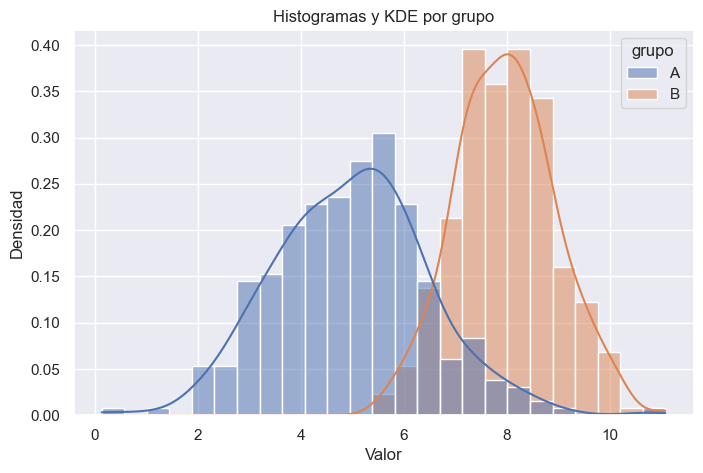

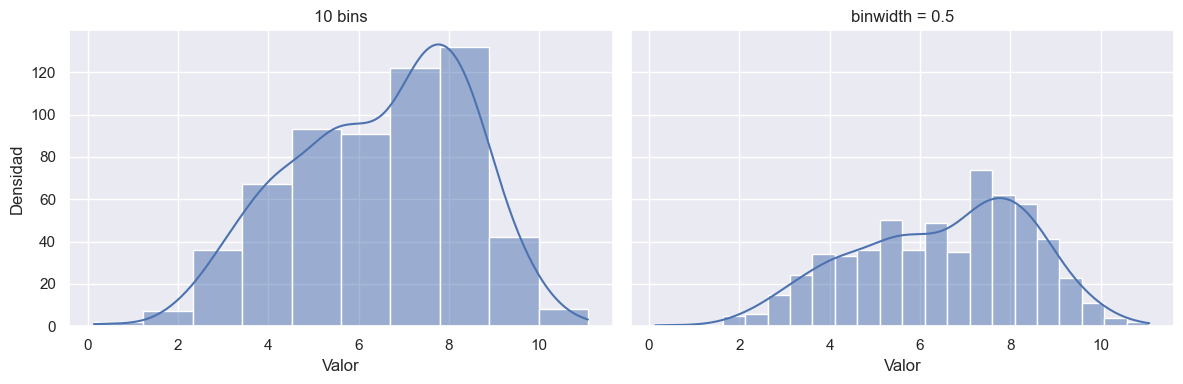

In [2]:
# Generamos datos sintéticos: dos grupos con distribuciones diferentes
np.random.seed(42)
grupo_a = np.random.normal(loc=5, scale=1.5, size=300)
grupo_b = np.random.normal(loc=8, scale=1.0, size=300)

datos = pd.DataFrame({
    "valor": np.concatenate([grupo_a, grupo_b]),
    "grupo": ["A"] * len(grupo_a) + ["B"] * len(grupo_b)
})

# Histograma con estimación de densidad para cada grupo
fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(data=datos, x="valor", hue="grupo", element="bars", stat="density",
             common_norm=False, bins=25, kde=True, ax=ax)
ax.set_title("Histogramas y KDE por grupo")
ax.set_xlabel("Valor")
ax.set_ylabel("Densidad")
plt.show()

# Comparación de binwidth vs bins
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
sns.histplot(datos["valor"], bins=10, kde=True, ax=axes[0])
axes[0].set_title("10 bins")

sns.histplot(datos["valor"], binwidth=0.5, kde=True, ax=axes[1])
axes[1].set_title("binwidth = 0.5")
for ax in axes:
    ax.set_xlabel("Valor")
    ax.set_ylabel("Densidad")
plt.tight_layout()
plt.show()

### 1.2 Boxplots y violin plots para detectar outliers

Los **boxplots** representan la mediana y los cuartiles de una distribución. La caja muestra el rango intercuartílico (IQR), mientras que las líneas (bigotes) se extienden a 1.5 × IQR; los puntos que quedan fuera de este rango se consideran *valores atípicos*. Un **violin plot** combina la información del boxplot con una estimación de densidad, mostrando la forma de la distribución a ambos lados de la mediana.

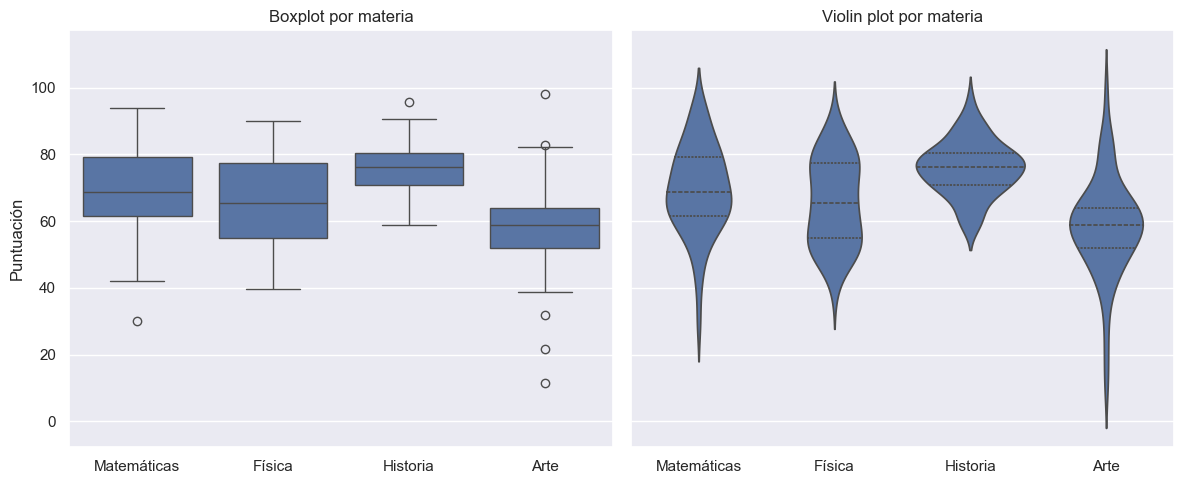

In [3]:
# Creamos un DataFrame con puntuaciones de examen para diferentes materias
np.random.seed(123)
materias = ["Matemáticas", "Física", "Historia", "Arte"]
datos_box = pd.DataFrame({
    "materia": np.repeat(materias, 50),
    "puntuación": np.concatenate([
        np.random.normal(70, 10, 50),    # Matemáticas
        np.random.normal(65, 12, 50),    # Física
        np.random.normal(75, 8, 50),     # Historia
        np.random.normal(60, 15, 50)     # Arte
    ])
})

# Introducimos algunos valores atípicos de forma intencionada
outliers = pd.DataFrame({
    "materia": ["Matemáticas", "Arte"],
    "puntuación": [30, 98]
})
datos_box = pd.concat([datos_box, outliers], ignore_index=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
sns.boxplot(data=datos_box, x="materia", y="puntuación", ax=axes[0])
axes[0].set_title("Boxplot por materia")
axes[0].set_xlabel("")
axes[0].set_ylabel("Puntuación")

sns.violinplot(data=datos_box, x="materia", y="puntuación", inner="quart", ax=axes[1])
axes[1].set_title("Violin plot por materia")
axes[1].set_xlabel("")
axes[1].set_ylabel("Puntuación")

plt.tight_layout()
plt.show()

## 2. Relaciones entre variables

Además de conocer la distribución individual de cada variable, es fundamental estudiar cómo se relacionan entre sí. Seaborn proporciona funciones para crear diagramas de dispersión y análisis multivariado de manera sencilla.

### 2.1 Diagramas de dispersión

El **scatterplot** es el gráfico básico para explorar la relación entre dos variables numéricas. Utilizando los argumentos `hue`, `style` o `size` puedes introducir variables categóricas adicionales y enriquecer la visualización.

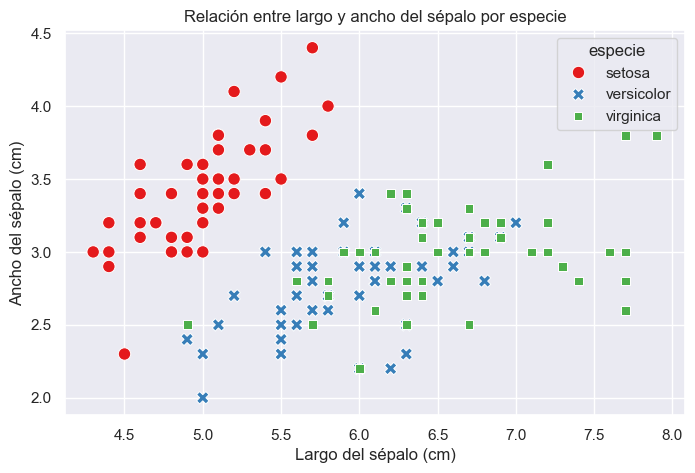

In [4]:
# Cargamos el conjunto de datos Iris desde scikit-learn
from sklearn.datasets import load_iris
iris = load_iris()
df_iris = pd.DataFrame(iris.data, columns=iris.feature_names)
df_iris["especie"] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Scatterplot para comparar largo vs ancho del sépalo y codificar la especie con colores y marcadores
fig, ax = plt.subplots(figsize=(8, 5))
sns.scatterplot(data=df_iris, x="sepal length (cm)", y="sepal width (cm)",
                hue="especie", style="especie", palette="Set1", s=80, ax=ax)
ax.set_title("Relación entre largo y ancho del sépalo por especie")
ax.set_xlabel("Largo del sépalo (cm)")
ax.set_ylabel("Ancho del sépalo (cm)")
plt.show()

### 2.2 Pairplot (gráficos de pares)

Cuando trabajas con más de dos variables numéricas, resulta útil visualizar todas las combinaciones posibles. La función **pairplot()** crea automáticamente una cuadrícula de gráficos donde cada fila y columna corresponde a una variable y se muestran las relaciones bivariadas y las distribuciones univariadas.

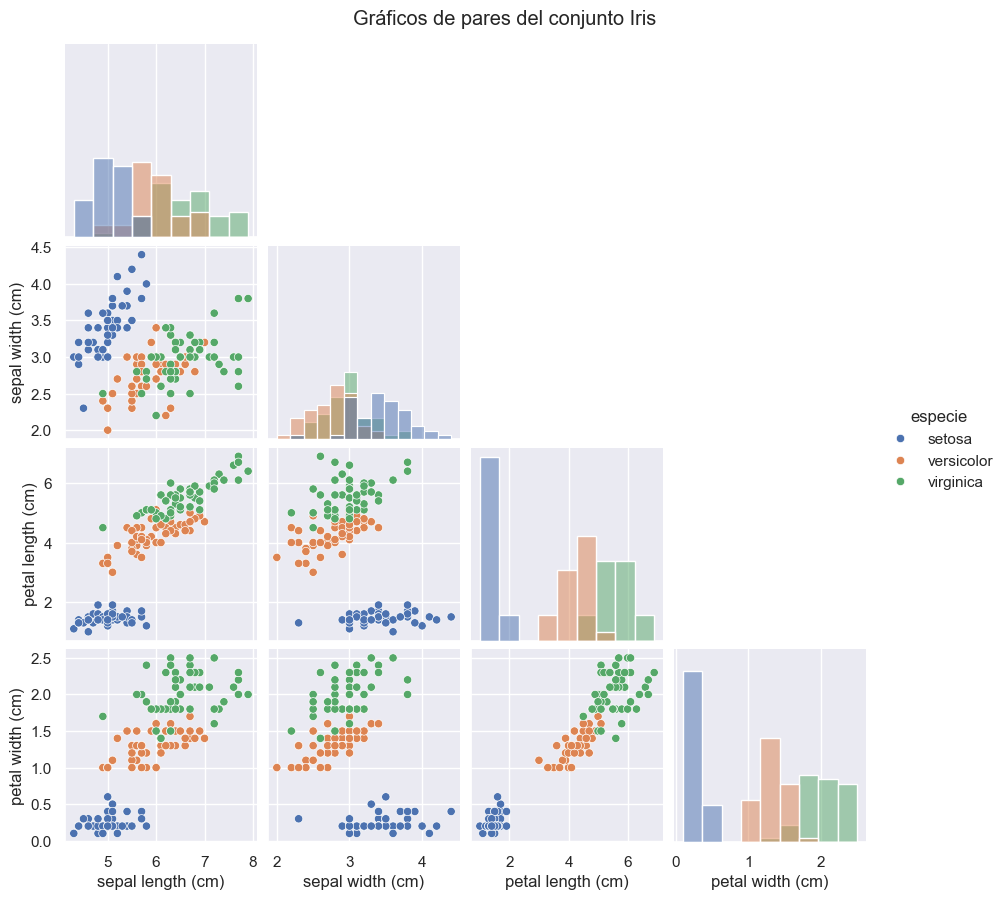

In [5]:
# Pairplot para todas las variables numéricas del Iris
sns.pairplot(df_iris, hue="especie", corner=True, diag_kind="hist", height=2.2)
plt.suptitle("Gráficos de pares del conjunto Iris", y=1.02)
plt.show()

### 2.3 Ajuste de regresiones

La función **regplot()** dibuja la nube de puntos y ajusta un modelo de regresión lineal. Puedes añadir líneas de confianza y estimar relaciones no lineales mediante polinomios o regresión LOWESS.

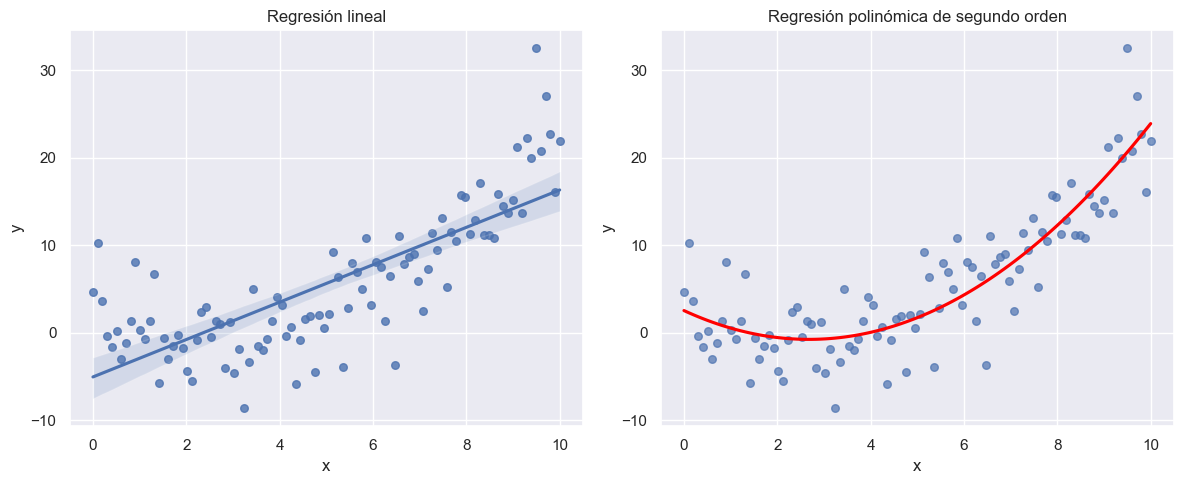

In [6]:
# Creamos una relación no lineal entre dos variables
np.random.seed(321)
x = np.linspace(0, 10, 100)
y = 0.5 * x**2 - 3 * x + 4 + np.random.normal(0, 4, size=len(x))

# DataFrame para regplot
df_reg = pd.DataFrame({"x": x, "y": y})

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# Ajuste lineal simple
sns.regplot(data=df_reg, x="x", y="y", ci=95, scatter_kws={"s": 30}, ax=axes[0])
axes[0].set_title("Regresión lineal")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")

# Ajuste polinómico de segundo orden (order=2)
sns.regplot(data=df_reg, x="x", y="y", order=2, ci=None, line_kws={"color": "red"},
            scatter_kws={"s": 30, "alpha": 0.7}, ax=axes[1])
axes[1].set_title("Regresión polinómica de segundo orden")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")

plt.tight_layout()
plt.show()

## 3. Mapas de calor y matrices de correlación

Los **mapas de calor** representan matrices numéricas mediante colores. Son ideales para mostrar una **matriz de correlación**, donde cada celda indica la correlación entre dos variables, o para cruzar variables categóricas.

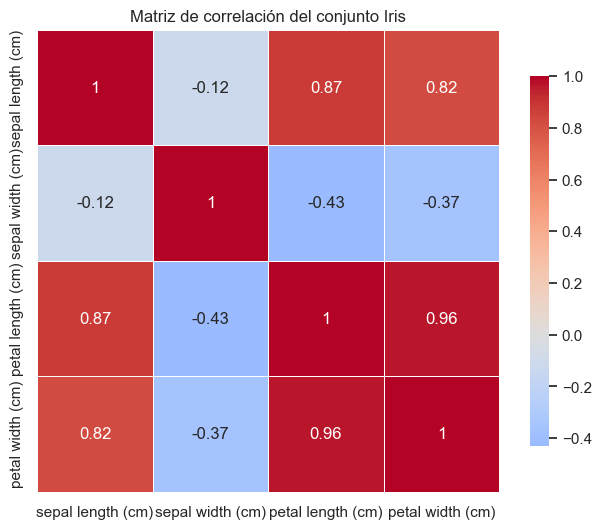

In [7]:
# Matriz de correlaciones de las variables del Iris
corr_matrix = df_iris.drop(columns=["especie"]).corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", center=0, square=True,
            linewidths=.5, cbar_kws={"shrink": .8})
plt.title("Matriz de correlación del conjunto Iris")
plt.show()

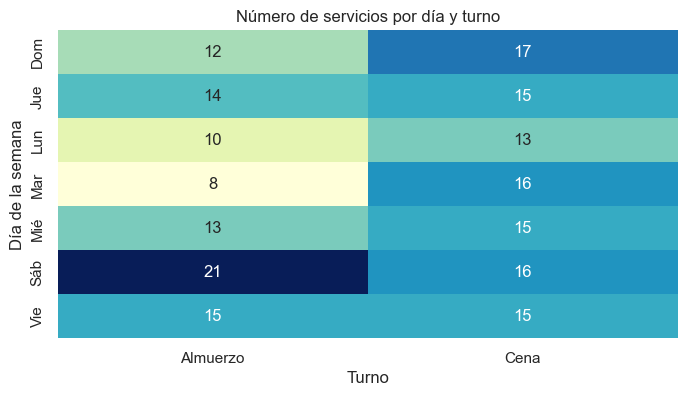

In [8]:
# Ejemplo de tabla de contingencia: contamos almuerzos y cenas en función del día de la semana
dias = ["Lun", "Mar", "Mié", "Jue", "Vie", "Sáb", "Dom"]
turnos = ["Almuerzo", "Cena"]
np.random.seed(456)
datos_cat = pd.DataFrame({
    "día": np.random.choice(dias, 200),
    "turno": np.random.choice(turnos, 200)
})

# Creamos tabla de contingencia
tabla = pd.crosstab(datos_cat["día"], datos_cat["turno"])

plt.figure(figsize=(8, 4))
sns.heatmap(tabla, annot=True, fmt="d", cmap="YlGnBu", cbar=False)
plt.title("Número de servicios por día y turno")
plt.xlabel("Turno")
plt.ylabel("Día de la semana")
plt.show()

## 4. Estilo y paletas de colores

Seaborn permite controlar la apariencia de los gráficos mediante temas y paletas. Puedes ajustar el contexto para cambiar el tamaño de fuente, seleccionar un estilo de ejes y escoger paletas coherentes con tus datos.

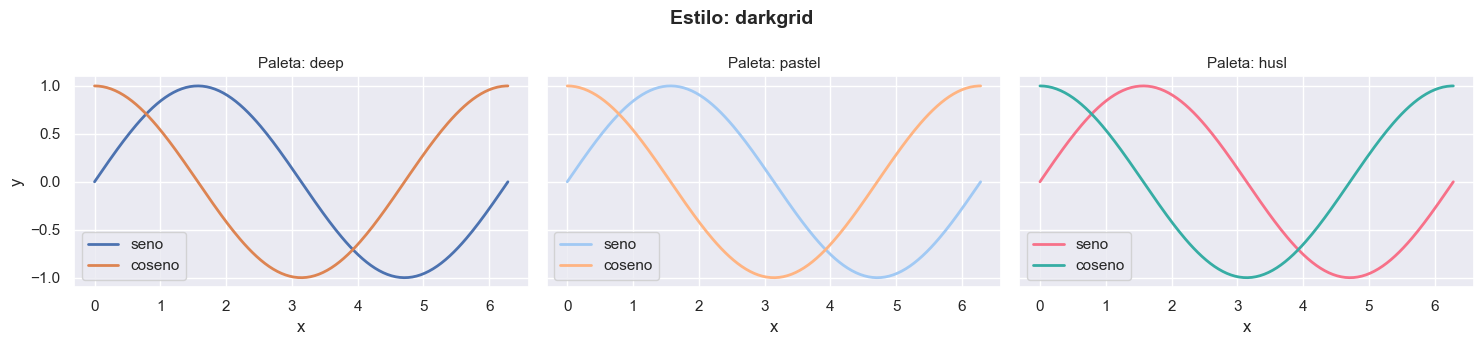

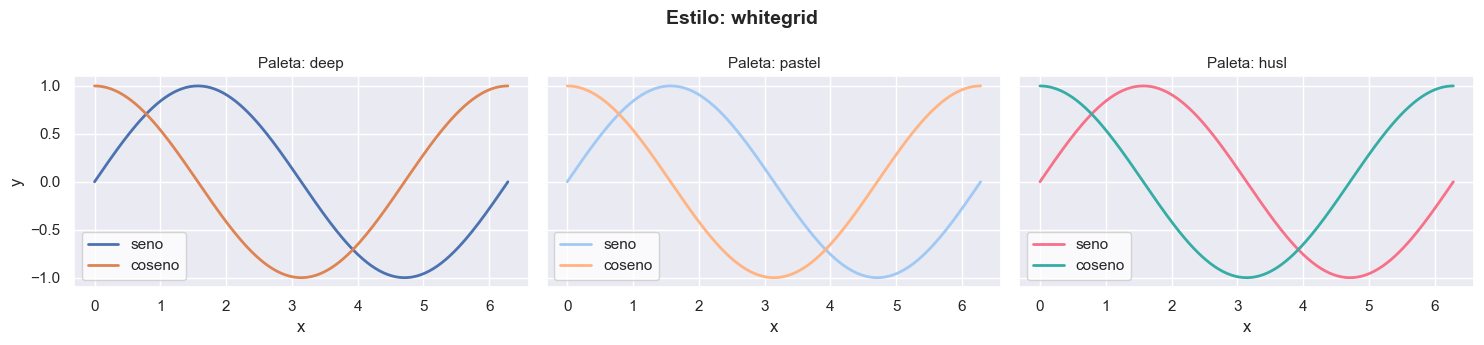

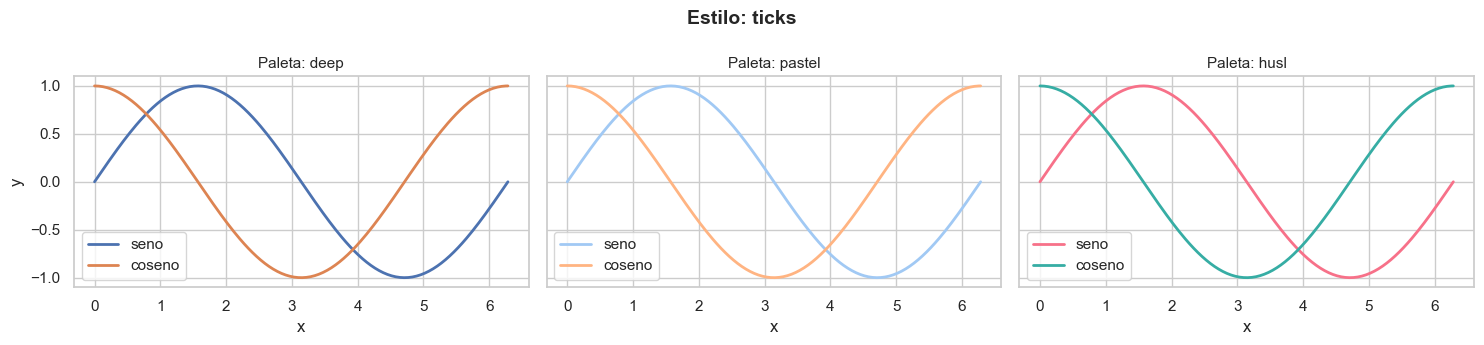

In [9]:
# Demostración de diferentes estilos y paletas
# Crear datos para ilustración
x = np.linspace(0, 2 * np.pi, 200)
y_sin = np.sin(x)
y_cos = np.cos(x)

estilos = ["darkgrid", "whitegrid", "ticks"]
paletas = ["deep", "pastel", "husl"]

# Crear una figura para cada combinación de estilo y paleta
for i, estilo in enumerate(estilos):
    fig, axes = plt.subplots(1, len(paletas), figsize=(15, 3.5), sharex=True, sharey=True)
    fig.suptitle(f"Estilo: {estilo}", fontsize=14, fontweight='bold')
    
    for j, paleta in enumerate(paletas):
        # Establecer el tema antes de graficar
        sns.set_theme(style=estilo, palette=paleta)
        
        # Obtener los colores de la paleta actual
        colors = sns.color_palette(paleta, n_colors=2)
        
        # Crear los datos para este subplot
        data_plot = pd.DataFrame({'x': x, 'seno': y_sin, 'coseno': y_cos})
        
        # Graficar con colores específicos de la paleta
        sns.lineplot(data=data_plot, x='x', y='seno', label="seno", ax=axes[j], 
                    linewidth=2, color=colors[0])
        sns.lineplot(data=data_plot, x='x', y='coseno', label="coseno", ax=axes[j], 
                    linewidth=2, color=colors[1])
        
        axes[j].set_title(f"Paleta: {paleta}", fontsize=11)
        axes[j].set_xlabel("x")
        axes[j].set_ylabel("y" if j == 0 else "")
        axes[j].legend()
    
    plt.tight_layout()
    plt.show()

# Restablecemos el tema por defecto para los siguientes gráficos
sns.set_theme()

## 5. Ejercicios propuestos

1. **Histogramas personalizados**: genera un conjunto de datos numéricos y crea un histograma comparando el efecto de diferentes números de barras y la opción `binwidth`.
2. **Detección de outliers**: crea un conjunto de datos con múltiples categorías y valores extremos. Visualízalo con un boxplot y un violin plot. ¿Qué diferencias observas?
3. **Análisis multivariante**: elige un conjunto de datos con al menos cuatro variables numéricas (puede ser el de Iris o uno propio) y genera un `pairplot()`. Añade un parámetro `hue` para una variable categórica y modifica `diag_kind`.
4. **Regresiones**: genera un conjunto de datos con ruido y ajusta modelos lineales y polinómicos de distintos grados usando `regplot()`. Compara visualmente los ajustes.
5. **Matrices de correlación**: toma cualquier DataFrame numérico y calcula su matriz de correlación. Representa la matriz con un mapa de calor y experimenta con diferentes paletas de colores y configuraciones como `center`, `vmin` y `vmax`.

### Conclusión

En este módulo has aprendido a utilizar Seaborn para explorar distribuciones de datos, analizar relaciones entre variables y visualizar matrices de correlación. Practicar con estas herramientas te permitirá contar historias basadas en datos de forma clara y efectiva. En el siguiente módulo trabajaremos con Plotly para añadir interactividad a tus visualizaciones.